# Flights Analytics Notebook

In [ ]:
### en terminal uv sync

## 1. Imports y configuración general

In [1]:
import os
import json
import getpass

import boto3
import pandas as pd
import awswrangler as wr
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

plt.style.use("ggplot")
pd.set_option("display.max_columns", 100)

## 2. Parámetros del proyecto

### Variables

- `REPLICA_ENDPOINT`: endpoint de la Read Replica
- `BUCKET`: bucket se escribe Bronze/Silver/Gold
- `ATHENA_OUTPUT`: carpeta para resultados de Athena
- `REGION`: normalmente `us-east-1`

### Credenciales PostgreSQL


In [2]:
REGION = os.getenv("AWS_REGION", "us-east-1")
REPLICA_ENDPOINT = os.getenv(
    "FLIGHTS_REPLICA_ENDPOINT",
    "itam-northwind-replica-494321812137.cqle2uw40pe8.us-east-1.rds.amazonaws.com",
)
BUCKET = os.getenv("FLIGHTS_BUCKET", "itam-analytics-hectorvil88")
ATHENA_OUTPUT = os.getenv("FLIGHTS_ATHENA_OUTPUT", f"s3://{BUCKET}/athena-results/")

USE_SECRETS_MANAGER = False
SECRET_ID = os.getenv("FLIGHTS_SECRET_ID", "itam/rds/northwind/credentials")

DB_USER = os.getenv("FLIGHTS_DB_USER", "itam")
DB_NAME = os.getenv("FLIGHTS_DB_NAME", "flights")
DB_PORT = int(os.getenv("FLIGHTS_DB_PORT", "5432"))
DB_PASSWORD = os.getenv("FLIGHTS_DB_PASSWORD")

if not USE_SECRETS_MANAGER and not DB_PASSWORD:
    try:
        DB_PASSWORD = getpass.getpass("Password PostgreSQL: ")
    except Exception:
        DB_PASSWORD = "****"

Password PostgreSQL:  ········


## 3. Construir conexiones

In [3]:
def get_pg_creds():
    if USE_SECRETS_MANAGER:
        client = boto3.client("secretsmanager", region_name=REGION)
        secret = client.get_secret_value(SecretId=SECRET_ID)
        payload = json.loads(secret["SecretString"])
        return {
            "username": payload["username"],
            "password": payload["password"],
            "dbname": payload["dbname"],
            "port": int(payload["port"]),
        }
    return {
        "username": DB_USER,
        "password": DB_PASSWORD,
        "dbname": DB_NAME,
        "port": DB_PORT,
    }


pg_creds = get_pg_creds()

engine_replica = create_engine(
    f"postgresql+psycopg2://{pg_creds['username']}:{pg_creds['password']}"
    f"@{REPLICA_ENDPOINT}:{pg_creds['port']}/{pg_creds['dbname']}"
)

def run_pg_query(sql: str) -> pd.DataFrame:
    return pd.read_sql(sql, engine_replica)

def run_athena_query(sql: str, database: str) -> pd.DataFrame:
    return wr.athena.read_sql_query(
        sql=sql,
        database=database,
        ctas_approach=False,
        s3_output=ATHENA_OUTPUT,
    )

## 4. Helpers para gráficas

In [4]:
def plot_bar(df: pd.DataFrame, x: str, y: str, title: str, rotation: int = 45):
    ax = df.plot(kind="bar", x=x, y=y, legend=False, figsize=(10, 4), title=title)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

def plot_line(df: pd.DataFrame, x: str, y: str, title: str):
    ax = df.plot(kind="line", x=x, y=y, marker="o", legend=False, figsize=(10, 4), title=title)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    plt.tight_layout()
    plt.show()

## 5. Validaciones iniciales

In [5]:
sql_counts = '''SELECT 'airlines' AS table_name, COUNT(*) AS total FROM airlines
UNION ALL
SELECT 'airports', COUNT(*) FROM airports
UNION ALL
SELECT 'flights', COUNT(*) FROM flights;'''
df_counts = run_pg_query(sql_counts)
df_counts

,table_name,total
0,airlines,14
1,airports,322
2,flights,500000


In [6]:
sql_w3_columns = '''SELECT column_name
FROM information_schema.columns
WHERE table_schema = 'public'
  AND table_name = 'flights'
  AND column_name IN ('flight_number', 'scheduled_departure');'''
df_w3_columns = run_pg_query(sql_w3_columns)
df_w3_columns

,column_name
0,flight_number
1,scheduled_departure


## 6. Preguntas P1–P5 (PostgreSQL)

In [7]:
P1_SQL = '''SELECT
    origin_airport,
    destination_airport,
    COUNT(*) AS total_flights
FROM flights
GROUP BY origin_airport, destination_airport
ORDER BY total_flights DESC, origin_airport, destination_airport
LIMIT 10;'''
DF_P1 = run_pg_query(P1_SQL)
DF_P1

,origin_airport,destination_airport,total_flights
0,LAX,JFK,1218
1,JFK,LAX,1217
2,SFO,LAX,1186
3,LAX,SFO,1172
4,LAS,LAX,1018
5,LAX,LAS,987
6,LGA,ORD,917
7,ORD,LGA,908
8,HNL,OGG,874
9,OGG,HNL,873


In [8]:
P2_SQL = '''SELECT
    airline,
    COUNT(*) AS total_flights,
    SUM(CASE WHEN cancelled = 1 THEN 1 ELSE 0 END) AS total_cancelled,
    ROUND(
        100.0 * SUM(CASE WHEN cancelled = 1 THEN 1 ELSE 0 END)::numeric / COUNT(*),
        2
    ) AS cancelled_pct
FROM flights
GROUP BY airline
ORDER BY cancelled_pct DESC, total_flights DESC
LIMIT 5;'''
DF_P2 = run_pg_query(P2_SQL)
DF_P2

,airline,total_flights,total_cancelled,cancelled_pct
0,MQ,31896,3136,9.83
1,B6,23062,1479,6.41
2,EV,52965,2523,4.76
3,US,35591,1268,3.56
4,UA,40873,1424,3.48


In [9]:
P3_SQL = '''SELECT
    cancellation_reason,
    COUNT(*) AS total_cancelled
FROM flights
WHERE cancellation_reason IS NOT NULL
GROUP BY cancellation_reason
ORDER BY total_cancelled DESC;'''
DF_P3 = run_pg_query(P3_SQL)
DF_P3

,cancellation_reason,total_cancelled
0,B,10630
1,A,3230
2,C,2962
3,D,2


In [10]:
P4_SQL = '''SELECT
    month,
    ROUND(AVG(departure_delay)::numeric, 2) AS avg_departure_delay
FROM flights
WHERE cancelled = 0
  AND departure_delay > 0
GROUP BY month
ORDER BY month;'''
DF_P4 = run_pg_query(P4_SQL)
DF_P4

,month,avg_departure_delay
0,1,32.57
1,2,42.31


In [11]:
P5_SQL = '''SELECT
    origin_airport,
    ROUND(SUM(weather_delay)::numeric, 2) AS total_weather_delay_minutes
FROM flights
GROUP BY origin_airport
ORDER BY total_weather_delay_minutes DESC NULLS LAST
LIMIT 10;'''
DF_P5 = run_pg_query(P5_SQL)
DF_P5

,origin_airport,total_weather_delay_minutes
0,ORD,102749.0
1,JFK,20542.0
2,LGA,13620.0
3,ATL,12562.0
4,DTW,12361.0
5,BOS,11361.0
6,DEN,8359.0
7,DCA,8188.0
8,PHX,7878.0
9,DFW,6870.0


### Visualizaciones P1–P5

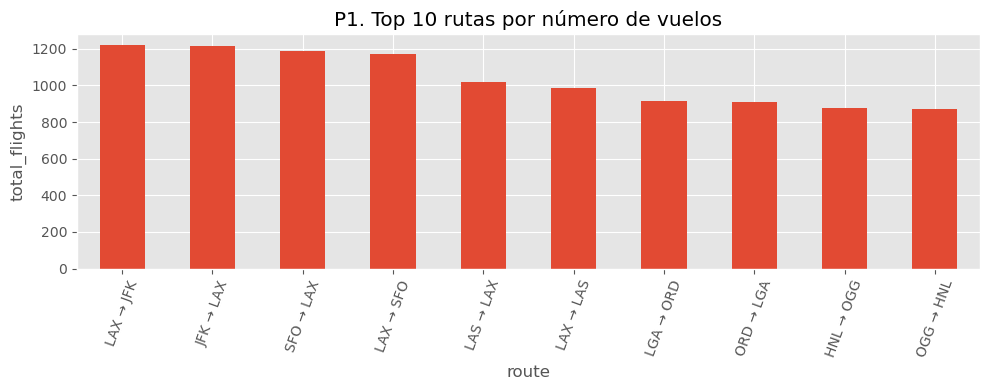

In [12]:
DF_P1["route"] = DF_P1["origin_airport"] + " → " + DF_P1["destination_airport"]
plot_bar(DF_P1, "route", "total_flights", "P1. Top 10 rutas por número de vuelos", rotation=70)

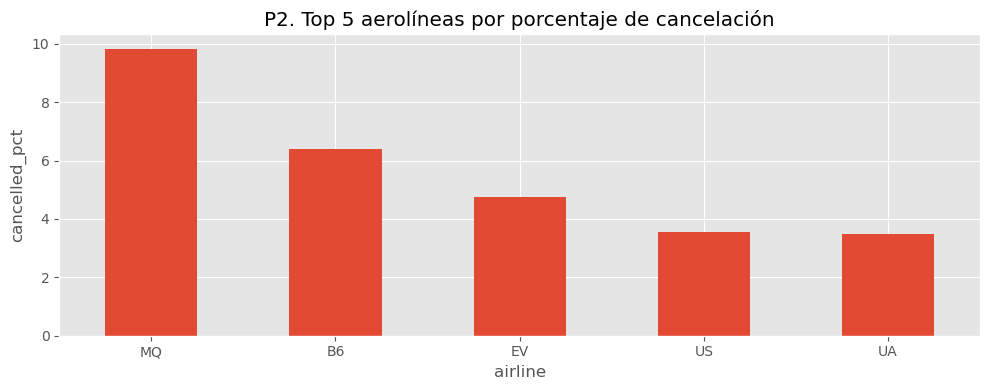

In [13]:
plot_bar(DF_P2, "airline", "cancelled_pct", "P2. Top 5 aerolíneas por porcentaje de cancelación", rotation=0)

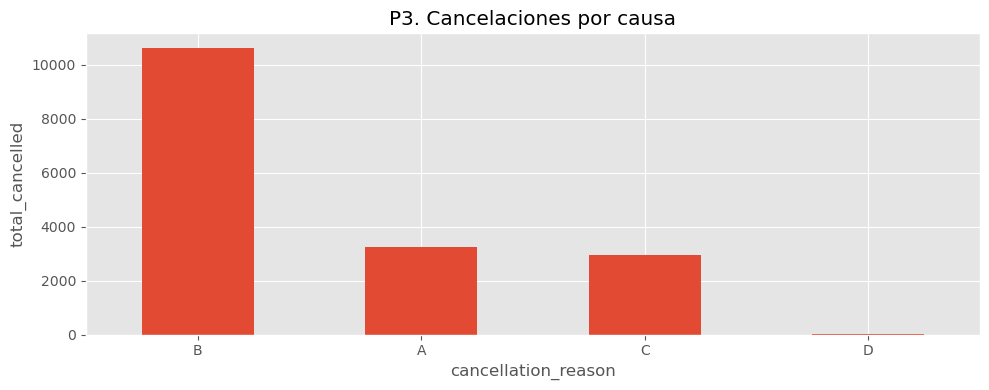

In [14]:
plot_bar(DF_P3, "cancellation_reason", "total_cancelled", "P3. Cancelaciones por causa", rotation=0)

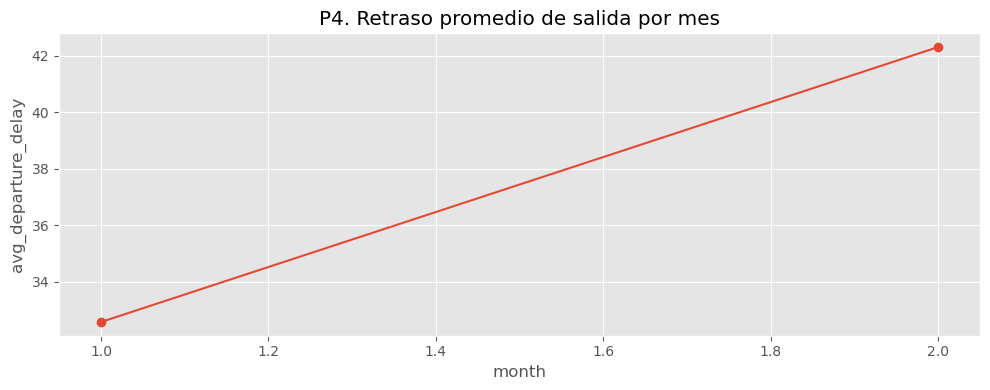

In [15]:
plot_line(DF_P4, "month", "avg_departure_delay", "P4. Retraso promedio de salida por mes")

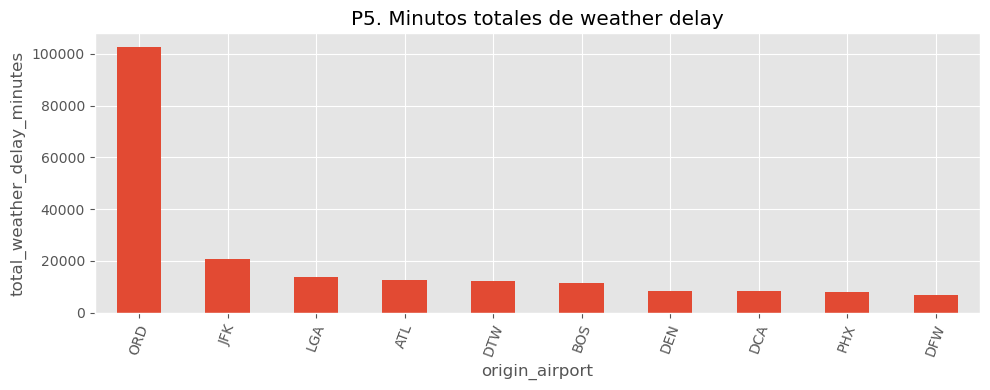

In [16]:
plot_bar(DF_P5, "origin_airport", "total_weather_delay_minutes", "P5. Minutos totales de weather delay", rotation=70)

## 7. Window Functions

### W1 — PostgreSQL

In [17]:
W1_SQL = '''WITH ranked AS (
    SELECT
        airline,
        origin_airport,
        destination_airport,
        arrival_delay,
        RANK() OVER (
            PARTITION BY airline
            ORDER BY arrival_delay DESC NULLS LAST
        ) AS rnk
    FROM flights
)
SELECT
    airline,
    origin_airport,
    destination_airport,
    arrival_delay
FROM ranked
WHERE rnk = 1
ORDER BY arrival_delay DESC NULLS LAST, airline;'''
DF_W1 = run_pg_query(W1_SQL)
DF_W1

,airline,origin_airport,destination_airport,arrival_delay
0,AA,BHM,DFW,1971.0
1,DL,MIA,MSP,1174.0
2,HA,JFK,HNL,1013.0
3,OO,CHO,ORD,953.0
4,UA,ICT,DEN,863.0
5,MQ,CLL,DFW,788.0
6,EV,SHV,DFW,723.0
7,F9,ORD,MIA,686.0
8,US,SEA,CLT,621.0
9,WN,IAD,DEN,593.0


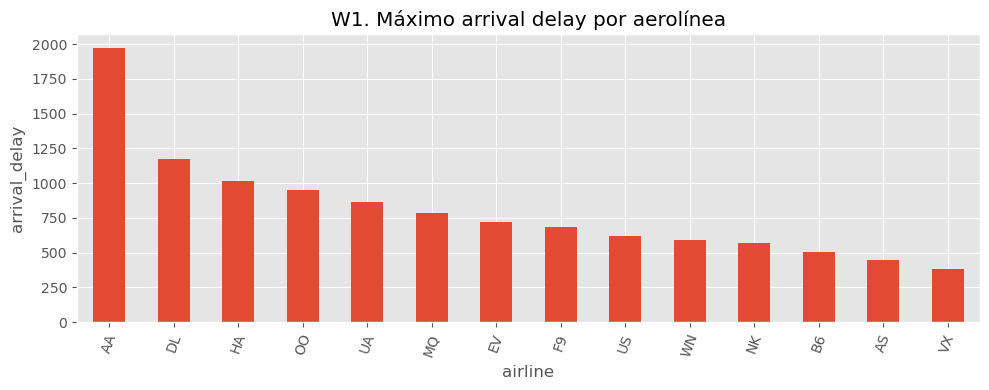

In [18]:
plot_bar(DF_W1.sort_values("arrival_delay", ascending=False), "airline", "arrival_delay", "W1. Máximo arrival delay por aerolínea", rotation=70)

### W2 — Athena

> Recuerda: esta pregunta se hace sobre `flights_silver.flights_monthly`, no sobre PostgreSQL.

In [19]:
W2_SQL = '''WITH monthly AS (
    SELECT
        month,
        SUM(total_flights) AS total_flights
    FROM flights_silver.flights_monthly
    GROUP BY month
)
SELECT
    month,
    total_flights,
    LAG(total_flights) OVER (ORDER BY month) AS prev_month_flights,
    total_flights - LAG(total_flights) OVER (ORDER BY month) AS diff_abs,
    ROUND(
        100.0 * (total_flights - LAG(total_flights) OVER (ORDER BY month))
        / NULLIF(LAG(total_flights) OVER (ORDER BY month), 0),
        2
    ) AS diff_pct
FROM monthly
ORDER BY month;'''
DF_W2 = run_athena_query(W2_SQL, 'flights_silver')
DF_W2

2026-04-15 07:12:23,979	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409960448 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.59gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-04-15 07:12:25,279	INFO worker.py:1852 -- Started a local Ray instance.


,month,total_flights,prev_month_flights,diff_abs,diff_pct
0,1,469968,<NA>,<NA>,NaN
1,2,429191,469968,-40777,-8.68
2,3,504312,429191,75121,17.50
3,4,485151,504312,-19161,-3.80
4,5,496993,485151,11842,2.44
5,6,503897,496993,6904,1.39
6,7,520718,503897,16821,3.34
7,8,510536,520718,-10182,-1.96
8,9,464946,510536,-45590,-8.93
9,10,486165,464946,21219,4.56


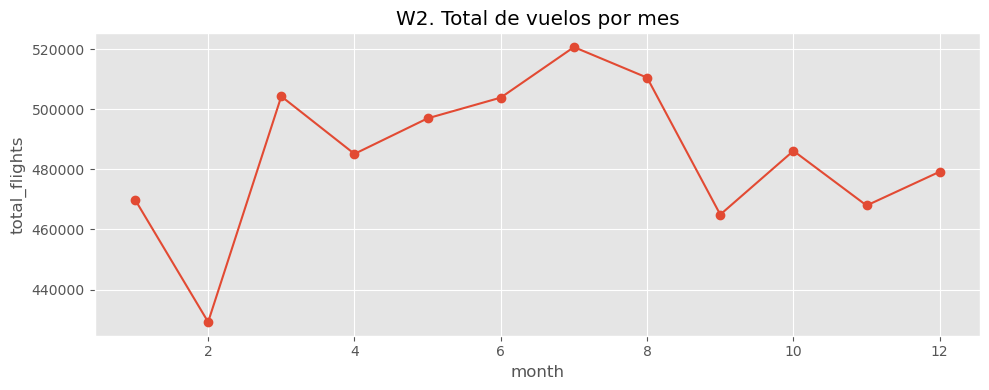

In [20]:
plot_line(DF_W2, "month", "total_flights", "W2. Total de vuelos por mes")

### W3 — PostgreSQL

In [21]:
W3_SQL = '''WITH ranked AS (
    SELECT
        year,
        month,
        day,
        origin_airport,
        flight_number,
        airline,
        destination_airport,
        scheduled_departure,
        ROW_NUMBER() OVER (
            PARTITION BY year, month, day, origin_airport
            ORDER BY scheduled_departure ASC
        ) AS rn
    FROM flights
    WHERE year = 2015
      AND month = 1
      AND day = 1
      AND origin_airport = 'LAX'
      AND scheduled_departure IS NOT NULL
)
SELECT
    flight_number,
    airline,
    destination_airport,
    LPAD(scheduled_departure::text, 4, '0') AS scheduled_departure
FROM ranked
WHERE rn <= 5
ORDER BY rn;'''
DF_W3 = run_pg_query(W3_SQL)
DF_W3

,flight_number,airline,destination_airport,scheduled_departure
0,2336,AA,PBI,0010
1,258,AA,MIA,0020
2,2013,US,CLT,0030
3,1434,DL,MSP,0035
4,115,AA,MIA,0105


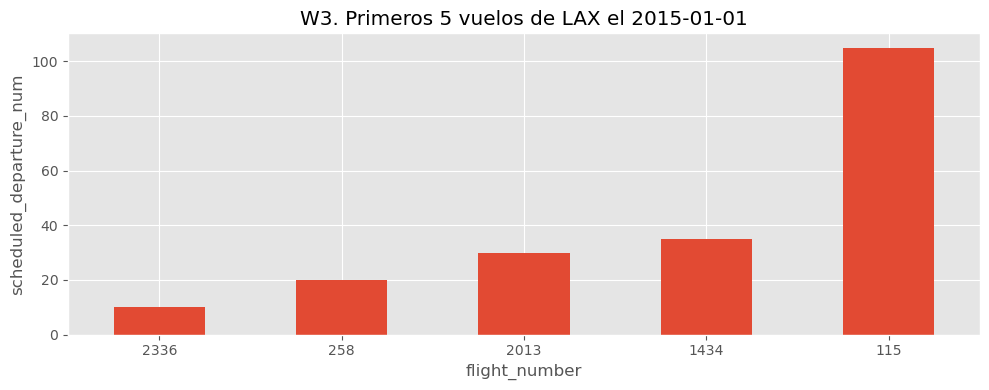

In [22]:
DF_W3_plot = DF_W3.copy()
DF_W3_plot["scheduled_departure_num"] = DF_W3_plot["scheduled_departure"].astype(int)
plot_bar(DF_W3_plot, "flight_number", "scheduled_departure_num", "W3. Primeros 5 vuelos de LAX el 2015-01-01", rotation=0)

## 8. Regresión lineal (8.1)


In [6]:
import numpy as np
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from sklearn.metrics import mean_squared_error

In [7]:
import awswrangler as wr

print("Antes:", wr.engine.get(), wr.memory_format.get())

wr.engine.set("python")
wr.memory_format.set("pandas")

print("Después:", wr.engine.get(), wr.memory_format.get())

Antes: EngineEnum.RAY MemoryFormatEnum.PANDAS
Después: EngineEnum.PYTHON MemoryFormatEnum.PANDAS


In [8]:
import awswrangler as wr

REG_SQL = """
SELECT
    arrival_delay,
    departure_delay,
    distance,
    air_system_delay,
    airline_delay,
    weather_delay,
    late_aircraft_delay,
    security_delay
FROM flights_gold.vuelos_analitica
WHERE cancelled = 0
  AND arrival_delay IS NOT NULL
"""

df_reg = wr.athena.read_sql_query(
    sql=REG_SQL,
    database="flights_gold",
    ctas_approach=True,   # explícito
    use_threads=False,    # menos picos de memoria
    s3_output=ATHENA_OUTPUT,
).dropna()

df_reg.shape

(1063439, 8)

In [6]:
REG_SQL = """
SELECT
    arrival_delay,
    departure_delay,
    distance,
    air_system_delay,
    airline_delay,
    weather_delay,
    late_aircraft_delay,
    security_delay
FROM flights_gold.vuelos_analitica
WHERE cancelled = 0
  AND arrival_delay IS NOT NULL
LIMIT 10000
"""
df_reg = run_athena_query(REG_SQL, "flights_gold").dropna()
df_reg.head()

2026-04-15 07:27:36,192	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409960448 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.59gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-04-15 07:27:37,461	INFO worker.py:1852 -- Started a local Ray instance.


,arrival_delay,departure_delay,distance,air_system_delay,airline_delay,weather_delay,late_aircraft_delay,security_delay
3,72.0,61.0,145,11.0,17.0,0.0,44.0,0.0
4,15.0,-6.0,2615,15.0,0.0,0.0,0.0,0.0
6,172.0,9.0,731,172.0,0.0,0.0,0.0,0.0
7,376.0,394.0,594,0.0,376.0,0.0,0.0,0.0
9,24.0,40.0,746,24.0,0.0,0.0,0.0,0.0


In [10]:
import pandas as pd
import statsmodels.api as sm

model_cols = [
    "arrival_delay",
    "departure_delay",
    "distance",
    "air_system_delay",
    "airline_delay",
    "weather_delay",
    "late_aircraft_delay",
    "security_delay",
]

df_model = df_reg[model_cols].copy()

# Forzar todo a numérico
for col in model_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Quitar filas con nulos después de la conversión
df_model = df_model.dropna()

y = df_model["arrival_delay"].astype(float)

X = df_model[
    [
        "departure_delay",
        "distance",
        "air_system_delay",
        "airline_delay",
        "weather_delay",
        "late_aircraft_delay",
        "security_delay",
    ]
].astype(float)

X_const = sm.add_constant(X, has_constant="add")
ols_model = sm.OLS(y, X_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          arrival_delay   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.928e+33
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:03   Log-Likelihood:             2.8694e+07
No. Observations:             1063439   AIC:                        -5.739e+07
Df Residuals:                 1063431   BIC:                        -5.739e+07
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                4.864e-13   8

In [11]:
df_reg.dtypes

arrival_delay          float64
departure_delay        float64
distance                 Int64
air_system_delay       float64
airline_delay          float64
weather_delay          float64
late_aircraft_delay    float64
security_delay         float64
dtype: object

In [12]:
y_hat = ols_model.predict(X_const)
residuals = y - y_hat

r2 = ols_model.rsquared
rmse = np.sqrt(mean_squared_error(y, y_hat))

print("R2:", round(r2, 4))
print("RMSE:", round(rmse, 4))

R2: 1.0
RMSE: 0.0


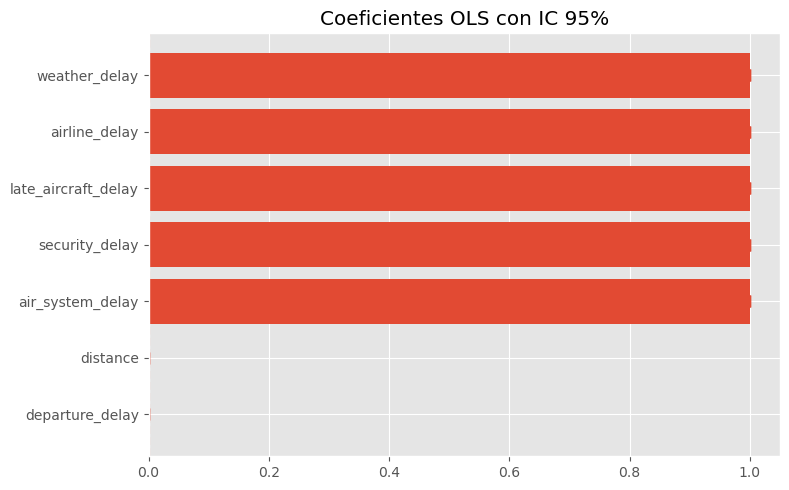

In [13]:
coef = ols_model.params.drop("const")
ci = ols_model.conf_int().loc[coef.index]

coef_df = pd.DataFrame(
    {
        "feature": coef.index,
        "coef": coef.values,
        "ci_low": ci[0].values,
        "ci_high": ci[1].values,
    }
).sort_values("coef")

plt.figure(figsize=(8, 5))
plt.barh(coef_df["feature"], coef_df["coef"])
plt.errorbar(
    coef_df["coef"],
    coef_df["feature"],
    xerr=[
        coef_df["coef"] - coef_df["ci_low"],
        coef_df["ci_high"] - coef_df["coef"],
    ],
    fmt="none",
    capsize=4,
)
plt.axvline(0, linestyle="--")
plt.title("Coeficientes OLS con IC 95%")
plt.tight_layout()
plt.show()

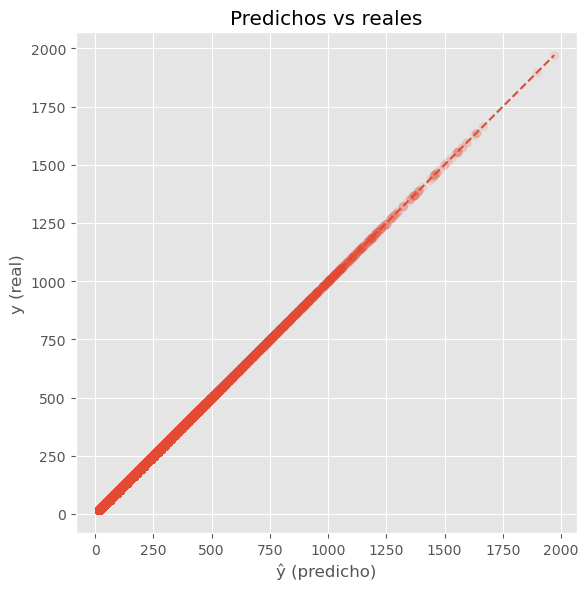

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_hat, y, alpha=0.1)
lims = [min(y_hat.min(), y.min()), max(y_hat.max(), y.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("ŷ (predicho)")
plt.ylabel("y (real)")
plt.title("Predichos vs reales")
plt.tight_layout()
plt.show()

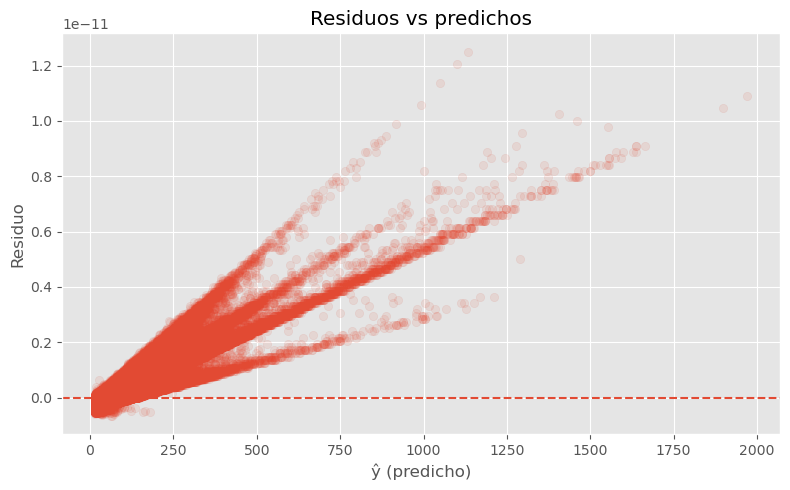

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(y_hat, residuals, alpha=0.1)
plt.axhline(0, linestyle="--")
plt.xlabel("ŷ (predicho)")
plt.ylabel("Residuo")
plt.title("Residuos vs predichos")
plt.tight_layout()
plt.show()

<Figure size 600x600 with 0 Axes>

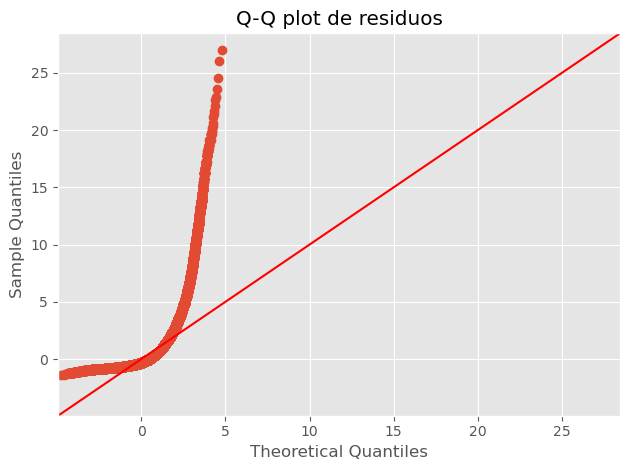

In [16]:
plt.figure(figsize=(6, 6))
qqplot(residuals, line="45", fit=True)
plt.title("Q-Q plot de residuos")
plt.tight_layout()
plt.show()

### Interpretación 

- qué coeficiente parece más importante
- qué tan alineados están los puntos en `ŷ` vs `y`
- si en residuos vs predichos aparece patrón
- si el Q-Q plot muestra colas alejadas de la normal

## 9. Forecast de series de tiempo (8.2)

In [17]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoARIMA, AutoTheta
from statsforecast.arima import arima_string
from sklearn.metrics import mean_absolute_error

In [18]:
TS_SQL = '''SELECT
    month,
    SUM(total_flights) AS total_flights
FROM flights_silver.flights_monthly
GROUP BY month
ORDER BY month'''
df_month = run_athena_query(TS_SQL, 'flights_silver')
df_month

,month,total_flights
0,1,469968
1,2,429191
2,3,504312
3,4,485151
4,5,496993
5,6,503897
6,7,520718
7,8,510536
8,9,464946
9,10,486165


In [19]:
df_ts = pd.DataFrame(
    {
        "unique_id": ["flights_2015"] * len(df_month),
        "ds": pd.to_datetime(
            {
                "year": [2015] * len(df_month),
                "month": df_month["month"].astype(int),
                "day": [1] * len(df_month),
            }
        ),
        "y": df_month["total_flights"].astype(float),
    }
)

df_ts

,unique_id,ds,y
0,flights_2015,2015-01-01,469968.0
1,flights_2015,2015-02-01,429191.0
2,flights_2015,2015-03-01,504312.0
3,flights_2015,2015-04-01,485151.0
4,flights_2015,2015-05-01,496993.0
5,flights_2015,2015-06-01,503897.0
6,flights_2015,2015-07-01,520718.0
7,flights_2015,2015-08-01,510536.0
8,flights_2015,2015-09-01,464946.0
9,flights_2015,2015-10-01,486165.0


In [20]:
train = df_ts[df_ts["ds"] <= "2015-09-01"].copy()
test = df_ts[df_ts["ds"] > "2015-09-01"].copy()

display(train)
display(test)

,unique_id,ds,y
0,flights_2015,2015-01-01,469968.0
1,flights_2015,2015-02-01,429191.0
2,flights_2015,2015-03-01,504312.0
3,flights_2015,2015-04-01,485151.0
4,flights_2015,2015-05-01,496993.0
5,flights_2015,2015-06-01,503897.0
6,flights_2015,2015-07-01,520718.0
7,flights_2015,2015-08-01,510536.0
8,flights_2015,2015-09-01,464946.0


,unique_id,ds,y
9,flights_2015,2015-10-01,486165.0
10,flights_2015,2015-11-01,467972.0
11,flights_2015,2015-12-01,479230.0


In [21]:
models = [
    AutoETS(season_length=12),
    AutoARIMA(season_length=12),
    AutoTheta(season_length=12),
]

sf = StatsForecast(models=models, freq="MS")
sf.fit(train)

forecast_df = sf.predict(h=9, level=[90]).reset_index()
forecast_df

,index,unique_id,ds,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90
0,0,flights_2015,2015-10-01,487319.908434,428025.166318,546614.650550,487301.333333,440427.078218,534175.588448,496523.548340,465489.479687,535667.421875
1,1,flights_2015,2015-11-01,487319.908434,428025.166022,546614.650847,487301.333333,440427.078218,534175.588448,496524.261068,460775.689063,525887.603125
2,2,flights_2015,2015-12-01,487319.908434,428025.165725,546614.651143,487301.333333,440427.078218,534175.588448,496524.973796,453725.757812,529276.887500
3,3,flights_2015,2016-01-01,487319.908434,428025.165429,546614.651440,487301.333333,440427.078218,534175.588448,496525.686524,460986.335938,525810.528125
4,4,flights_2015,2016-02-01,487319.908434,428025.165132,546614.651736,487301.333333,440427.078218,534175.588448,496526.399252,466634.279687,533010.103125
5,5,flights_2015,2016-03-01,487319.908434,428025.164836,546614.652033,487301.333333,440427.078218,534175.588448,496527.111980,463863.089062,530507.737500
6,6,flights_2015,2016-04-01,487319.908434,428025.164539,546614.652329,487301.333333,440427.078218,534175.588448,496527.824708,460121.359375,532280.328125
7,7,flights_2015,2016-05-01,487319.908434,428025.164243,546614.652625,487301.333333,440427.078218,534175.588448,496528.537435,461351.543750,532693.590625
8,8,flights_2015,2016-06-01,487319.908434,428025.163947,546614.652922,487301.333333,440427.078218,534175.588448,496529.250163,459872.057812,532316.259375


In [22]:
autoets_fitted = getattr(sf.fitted_[0, 0], "model_", sf.fitted_[0, 0])
autoarima_fitted = getattr(sf.fitted_[0, 1], "model_", sf.fitted_[0, 1])
autotheta_fitted = getattr(sf.fitted_[0, 2], "model_", sf.fitted_[0, 2])

print("AutoARIMA:", arima_string(autoarima_fitted))

if isinstance(autotheta_fitted, dict) and "modeltype" in autotheta_fitted:
    print("AutoTheta:", autotheta_fitted["modeltype"])
else:
    print("AutoTheta:", autotheta_fitted)

print("AutoETS fitted object:")
print(autoets_fitted)

AutoARIMA: ARIMA(0,0,0) with non-zero mean
AutoTheta: OTM
AutoETS fitted object:
{'loglik': -101.67609124578684, 'aic': 209.35218249157367, 'bic': 209.94385622358232, 'aicc': 214.15218249157368, 'mse': 721947057.1865228, 'amse': 633014584.3963304, 'fit': results(x=array([1.00000000e-04, 4.87319922e+05]), fn=203.35218249157367, nit=29, simplex=array([[1.00000000e-04, 4.87223631e+05],
       [1.00000000e-04, 4.87346691e+05],
       [1.00000000e-04, 4.87319922e+05]])), 'residuals': array([-17351.92240399, -58127.18721175,  16999.62550698,  -2163.07445557,
         9679.14185187,  16582.17393769,  33401.51572029,  23216.17556872,
       -22376.14604884]), 'components': 'ANNN', 'm': 1, 'nstate': 1, 'fitted': array([487319.92240399, 487318.18721175, 487312.37449302, 487314.07445557,
       487313.85814813, 487314.82606231, 487316.48427971, 487319.82443128,
       487322.14604884]), 'states': array([[487319.92240399],
       [487318.18721175],
       [487312.37449302],
       [487314.07445557

In [23]:
pred_test = forecast_df.iloc[:3].copy()
future_6 = forecast_df.iloc[3:].copy()

mae_df = pd.DataFrame(
    {
        "model": ["AutoETS", "AutoARIMA", "AutoTheta"],
        "mae": [
            mean_absolute_error(test["y"], pred_test["AutoETS"]),
            mean_absolute_error(test["y"], pred_test["AutoARIMA"]),
            mean_absolute_error(test["y"], pred_test["AutoTheta"]),
        ],
    }
).sort_values("mae")

mae_df

,model,mae
1,AutoARIMA,9512.333333
0,AutoETS,9530.908434
2,AutoTheta,18735.261068


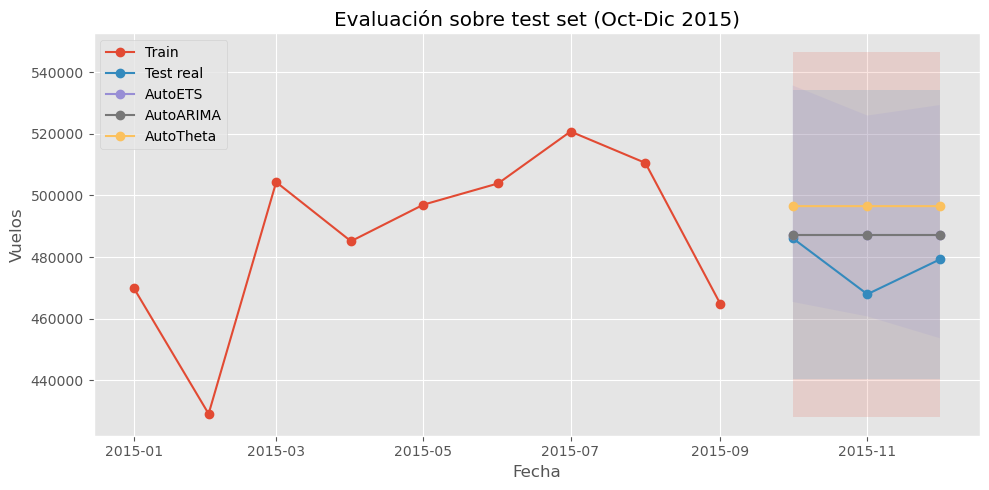

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(train["ds"], train["y"], marker="o", label="Train")
plt.plot(test["ds"], test["y"], marker="o", label="Test real")

for model_name in ["AutoETS", "AutoARIMA", "AutoTheta"]:
    plt.plot(pred_test["ds"], pred_test[model_name], marker="o", label=model_name)
    plt.fill_between(
        pred_test["ds"],
        pred_test[f"{model_name}-lo-90"],
        pred_test[f"{model_name}-hi-90"],
        alpha=0.15,
    )

plt.title("Evaluación sobre test set (Oct-Dic 2015)")
plt.xlabel("Fecha")
plt.ylabel("Vuelos")
plt.legend()
plt.tight_layout()
plt.show()

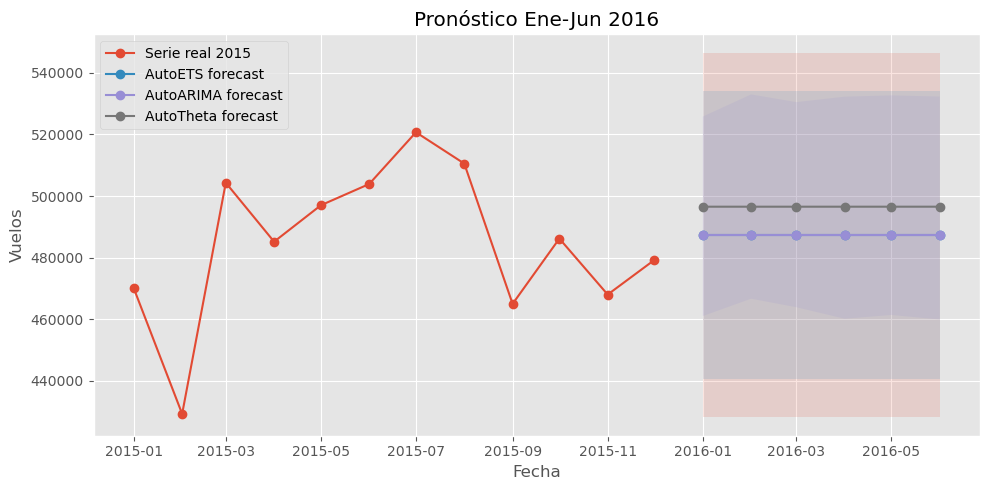

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(df_ts["ds"], df_ts["y"], marker="o", label="Serie real 2015")

for model_name in ["AutoETS", "AutoARIMA", "AutoTheta"]:
    plt.plot(future_6["ds"], future_6[model_name], marker="o", label=f"{model_name} forecast")
    plt.fill_between(
        future_6["ds"],
        future_6[f"{model_name}-lo-90"],
        future_6[f"{model_name}-hi-90"],
        alpha=0.15,
    )

plt.title("Pronóstico Ene-Jun 2016")
plt.xlabel("Fecha")
plt.ylabel("Vuelos")
plt.legend()
plt.tight_layout()
plt.show()

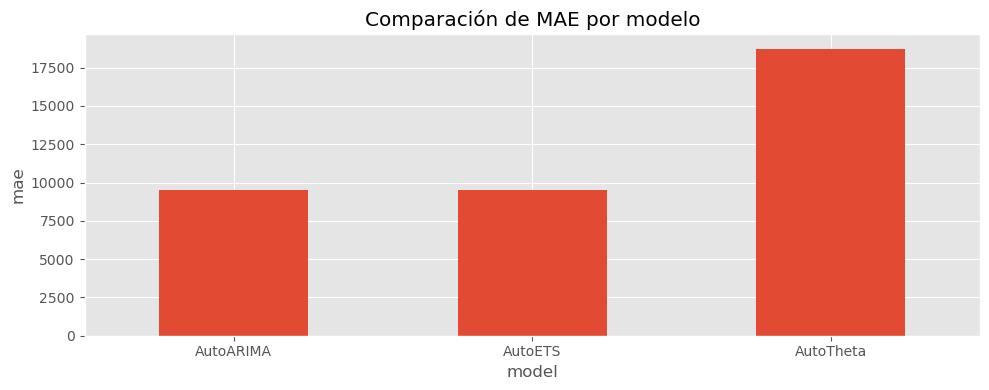

In [26]:
plot_bar(mae_df, "model", "mae", "Comparación de MAE por modelo", rotation=0)

### Interpretación 

En el test set, AutoARIMA y AutoETS muestran el mejor desempeño y registran los menores valores de MAE, mientras que AutoTheta queda  por detrás. Las bandas de confianza al 90% se ven amplias y se sobreponen entre los modelos, lo que indica una incertidumbre importante en la proyección, dado que el entrenamiento utiliza solo 9 meses de información y no alcanza a cubrir dos ciclos estacionales completos, el pronóstico debe interpretarse como una aproximación  del nivel de vuelos, pero no como una proyección de alta precisión.